# Bab 7: Unsupervised Learning

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)

## Ringkasan Bab
**Unsupervised learning** mengambil struktur dari data **tanpa outcome berlabel**. Metode ini dipakai untuk eksplorasi, reduksi dimensi, dan membuat fitur atau segmen untuk model supervised berikutnya.

1. **Principal Components Analysis (PCA).** Variabel baru yang tidak berkorelasi dan menangkap sebagian besar varians, dengan scree plot dan loading, ditambah correspondence analysis untuk tabel kategorikal.
2. **Clustering K-Means.** Data dibagi menjadi K kelompok dengan meminimalkan jarak dalam kelompok, serta cara memilih K (elbow) dan penskalaan.
3. **Hierarchical clustering.** Dendrogram, algoritma agglomerative, dan metode linkage.
4. **Model-based clustering.** Gaussian mixture model yang dipasang dengan EM, dan jumlah klaster dipilih dengan BIC.
5. **Penskalaan dan variabel kategorikal.** Standarisasi, variabel dominan, jarak Gower, dan one-hot encoding.

In [1]:
import math
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import multivariate_normal
import prince
from adjustText import adjust_text
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

DATA = Path('..') / 'data'
sns.set_style('whitegrid')

## 1. Principal Components Analysis (PCA)
**Penjelasan teori.** Banyak variabel saling berkorelasi dan membawa informasi yang berulang. PCA menggabungkan prediktor secara linear menjadi **komponen utama** yang:
- **Ortogonal (tidak berkorelasi)** satu sama lain;
- diurutkan sehingga **komponen pertama** menjelaskan porsi varians total terbesar, komponen kedua menjelaskan porsi terbesar berikutnya (ortogonal terhadap yang pertama), dan seterusnya.

Secara matematis, komponen-komponennya adalah eigenvector dari matriks kovarians (atau korelasi), dan **eigenvalue**-nya sama dengan varians yang dijelaskan. **Loading** (bobot) menunjukkan kontribusi tiap variabel asli ke sebuah komponen, sedangkan **skor komponen** adalah data hasil transformasi.

- **Scree plot** menampilkan varians tiap komponen. Titik "siku"-nya dipakai untuk menentukan berapa komponen yang dipertahankan.
- Variabel perlu **distandarkan** dulu kalau skalanya berbeda (PCA pada matriks korelasi).
- PCA sensitif terhadap outlier, dan berguna untuk reduksi dimensi, visualisasi, dan menghilangkan multikolinearitas.

In [2]:
sp500_px = pd.read_csv(DATA / 'sp500_data.csv.gz', index_col=0)
oil_px = sp500_px[['XOM', 'CVX']]
print(oil_px.head())

pcs = PCA(n_components=2)
pcs.fit(oil_px)
loadings = pd.DataFrame(pcs.components_, columns=oil_px.columns)
print(loadings)

                 XOM       CVX
1993-01-29 -0.016991  0.072921
1993-02-01  0.016991  0.102089
1993-02-02  0.084954  0.029168
1993-02-03  0.067964  0.058337
1993-02-04  0.034378  0.044272
        XOM       CVX
0  0.664711  0.747101
1  0.747101 -0.664711


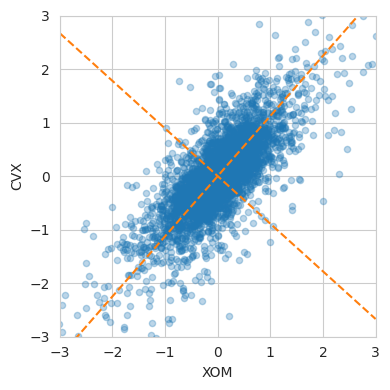

In [3]:
def abline(slope, intercept, ax):
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

ax = oil_px.plot.scatter(x='XOM', y='CVX', alpha=0.3, figsize=(4, 4))
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.plot(*abline(loadings.loc[0, 'CVX'] / loadings.loc[0, 'XOM'], 0, ax), '--', color='C1')
ax.plot(*abline(loadings.loc[1, 'CVX'] / loadings.loc[1, 'XOM'], 0, ax), '--', color='C1')
plt.tight_layout(); plt.show()

Komponen utama pertama (garis putus-putus sepanjang awan titik) adalah kombinasi berbobot yang menangkap pergerakan bersama kedua saham minyak, sedangkan komponen kedua menangkap sisanya.

### Menafsirkan Komponen Utama

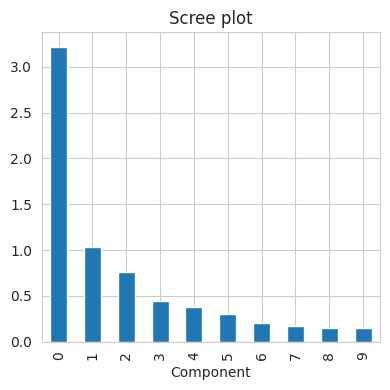

Cumulative variance explained: [0.445 0.588 0.693 0.755 0.809 0.85 ]


In [4]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
               'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]

sp_pca = PCA()
sp_pca.fit(top_sp)

explained_variance = pd.DataFrame(sp_pca.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component'); ax.set_title('Scree plot')
plt.tight_layout(); plt.show()
print('Cumulative variance explained:', np.round(np.cumsum(sp_pca.explained_variance_ratio_)[:6], 3))

       AAPL       AXP       COP      COST      CSCO       CVX        HD  \
0  0.300825  0.246332  0.261529  0.273634  0.064059  0.444490  0.207983   
1  0.505116  0.139426 -0.174212  0.416307  0.031939 -0.289373  0.278002   
2  0.786730 -0.135458  0.002367 -0.465862  0.007524 -0.082374 -0.166320   
3 -0.120586  0.061814 -0.206026  0.092596  0.003904 -0.577665  0.162814   
4 -0.111576  0.596666  0.005813 -0.555529  0.039860 -0.109016  0.185488   

       INTC       JPM      MSFT       SLB       TGT       USB       WFC  \
0  0.076956  0.196397  0.105012  0.481786  0.148833  0.116421  0.145684   
1  0.033898  0.040723  0.053954 -0.472494  0.228123  0.054796  0.047427   
2  0.003518 -0.062261 -0.016248  0.194822 -0.160833 -0.048976 -0.041932   
3 -0.001605  0.057687 -0.012558  0.680914  0.109895  0.016752  0.018614   
4  0.072047  0.385160  0.077135 -0.181332  0.055557  0.155440  0.216425   

        WMT       XOM  
0  0.122304  0.317952  
1  0.222889 -0.154192  
2 -0.175806 -0.090167  
3 

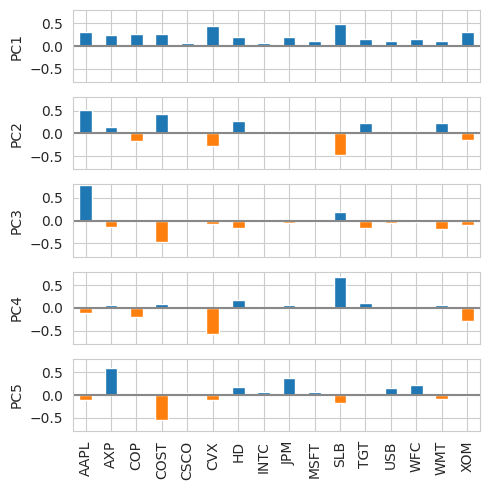

In [5]:
loadings = pd.DataFrame(sp_pca.components_[0:5, :], columns=top_sp.columns)
print(loadings)

maxPC = 1.01 * loadings.loc[0:5, :].abs().to_numpy().max()
f, axes = plt.subplots(5, 1, figsize=(5, 5), sharex=True)
for i, ax in enumerate(axes):
    pc_loadings = loadings.loc[i, :]
    colors = ['C0' if l > 0 else 'C1' for l in pc_loadings]
    ax.axhline(color='#888888')
    pc_loadings.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'PC{i+1}'); ax.set_ylim(-maxPC, maxPC)
plt.tight_layout(); plt.show()

- **PC1:** semua loading bertanda sama, artinya pergerakan *pasar* secara keseluruhan.
- **PC2:** membedakan saham minyak/energi dari saham lainnya, jadi ini faktor *energi dibanding yang lain*.
- **PC3 sampai PC5:** membedakan saham keuangan dari teknologi/ritel dan kontras sektor lainnya.

### Correspondence Analysis
**Penjelasan teori.** Ini padanan PCA untuk data **kategorikal** dalam **tabel kontingensi** (misalnya siapa di rumah yang mengerjakan tiap tugas). Metodenya menguraikan jarak chi-square antar baris dan kolom, lalu menampilkan baris dan kolom **bersama-sama dalam satu biplot**. Item yang berdekatan berarti berasosiasi kuat.

           Wife  Alternating  Husband  Jointly
Task                                          
Laundry     156           14        2        4
Main_meal   124           20        5        4
Dinner       77           11        7       13
Breakfast    82           36       15        7
Tidying      53           11        1       57
Dishes       32           24        4       53
Shopping     33           23        9       55
Official     12           46       23       15
Driving      10           51       75        3
Finances     13           13       21       66
Insurance     8            1       53       77
Repairs       0            3      160        2
Holidays      0            1        6      153


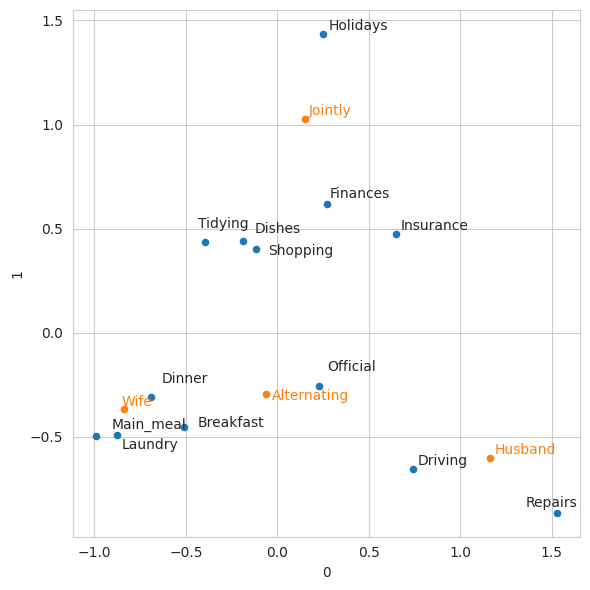

In [6]:
housetasks = pd.read_csv(DATA / 'housetasks.csv', index_col=0)
print(housetasks)

ca = prince.CA(n_components=2)
ca = ca.fit(housetasks)
rows = ca.row_coordinates(housetasks)
cols = ca.column_coordinates(housetasks)

fig, ax = plt.subplots(figsize=(6, 6))
rows.plot.scatter(x=0, y=1, ax=ax)
cols.plot.scatter(x=0, y=1, ax=ax, c='C1')
texts = []
for idx, row in rows.iterrows():
    texts.append(ax.text(row[0], row[1], idx))
for idx, row in cols.iterrows():
    texts.append(ax.text(row[0], row[1], idx, color='C1'))
adjust_text(texts)
plt.tight_layout(); plt.show()

## 2. Clustering K-Means
**Penjelasan teori.** **Clustering** mengelompokkan record agar anggota satu klaster mirip satu sama lain dan berbeda dari klaster lain. Langkah **K-means** (MacQueen/Lloyd):
1. Pilih *K* dan inisialisasi *K* **centroid** (k-means++ menyebarkannya).
2. **Tetapkan** tiap record ke centroid terdekat.
3. **Perbarui** tiap centroid menjadi rata-rata anggotanya.
4. Ulangi sampai penetapan tidak berubah lagi.

Metode ini meminimalkan **jumlah kuadrat dalam klaster**: $\sum_k\sum_{i\in C_k}\lVert x_i-\mu_k\rVert^2$. Hasilnya hanya konvergen ke **optimum lokal**, jadi sebaiknya dijalankan dengan beberapa inisialisasi acak (`n_init`). **Rata-rata** tiap klaster merangkum karakter segmennya.

**Memilih K dengan metode elbow.** Plot jumlah kuadrat dalam klaster (rata-rata) terhadap *K*, lalu pilih titik ketika penurunannya mulai melandai. Pertimbangan lain: silhouette score dan pengetahuan domain. K-means butuh data numerik dan cenderung cocok untuk klaster yang kira-kira bulat dengan ukuran serupa.

                 XOM       CVX  cluster
2011-01-03  0.736805  0.240681        3
2011-01-04  0.168668 -0.584516        0
2011-01-05  0.026631  0.446985        3
2011-01-06  0.248558 -0.919751        0
2011-01-07  0.337329  0.180511        3
        XOM       CVX
0 -0.286422 -0.492965
1  1.092072  1.581077
2 -1.123045 -1.718845
3  0.325846  0.449970


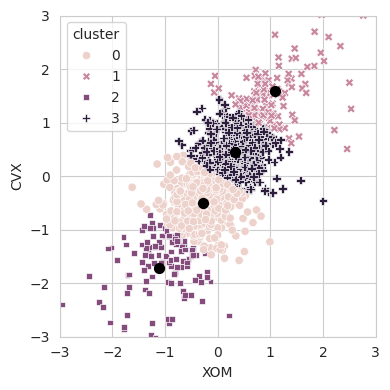

In [7]:
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']].copy()
kmeans = KMeans(n_clusters=4, n_init='auto', random_state=1).fit(df)
df['cluster'] = kmeans.labels_
print(df.head())
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['XOM', 'CVX'])
print(centers)

fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.scatterplot(x='XOM', y='CVX', hue='cluster', style='cluster', ax=ax, data=df)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
centers.plot.scatter(x='XOM', y='CVX', ax=ax, s=50, color='black')
plt.tight_layout(); plt.show()

Counter({np.int32(4): 322, np.int32(1): 271, np.int32(0): 256, np.int32(3): 152, np.int32(2): 130})


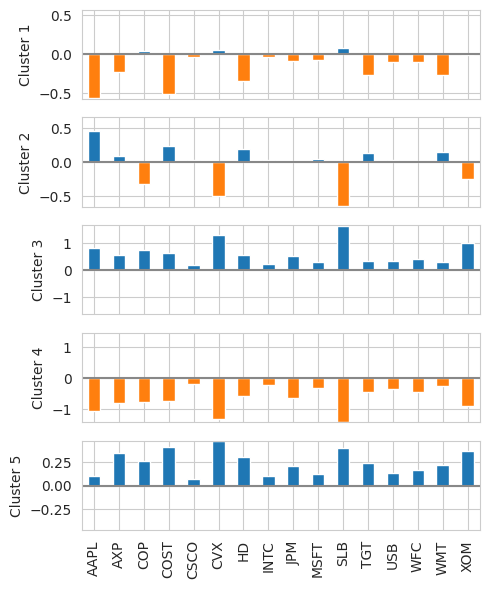

In [8]:
# Interpreting the clusters (daily returns for 16 stocks, K=5)
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
               'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]
kmeans = KMeans(n_clusters=5, n_init='auto', random_state=1).fit(top_sp)
print(Counter(kmeans.labels_))

centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)
f, axes = plt.subplots(5, 1, figsize=(5, 6), sharex=True)
for i, ax in enumerate(axes):
    center = centers.loc[i, :]
    maxPC = 1.01 * np.max(np.abs(center))
    colors = ['C0' if l > 0 else 'C1' for l in center]
    ax.axhline(color='#888888')
    center.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'Cluster {i + 1}'); ax.set_ylim(-maxPC, maxPC)
plt.tight_layout(); plt.show()

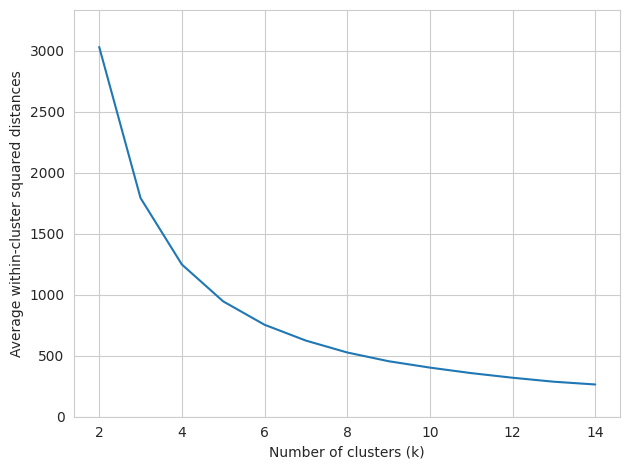

In [9]:
# Selecting the number of clusters: elbow method
inertia = []
for n_clusters in range(2, 15):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto').fit(top_sp)
    inertia.append(kmeans.inertia_ / n_clusters)

inertias = pd.DataFrame({'n_clusters': range(2, 15), 'inertia': inertia})
ax = inertias.plot(x='n_clusters', y='inertia')
plt.xlabel('Number of clusters (k)'); plt.ylabel('Average within-cluster squared distances')
plt.ylim((0, 1.1 * inertias.inertia.max()))
ax.legend().set_visible(False)
plt.tight_layout(); plt.show()

## 3. Hierarchical Clustering
**Penjelasan teori.** Metode ini membangun **hierarki klaster bersarang** yang ditampilkan sebagai **dendrogram**. Kita tidak perlu menetapkan *K* di awal, karena pohonnya bisa dipotong di ketinggian mana pun. Cocok untuk data kecil dan memperlihatkan struktur pada beberapa tingkat.

**Algoritma agglomerative (dari bawah ke atas).** Mulai dengan tiap record sebagai klaster sendiri, lalu berulang kali **gabungkan dua klaster yang paling dekat** sampai tersisa satu. *Ketidakmiripan* antar klaster bergantung pada metode **linkage**:
- **Single:** jarak minimum antar anggota, menghasilkan klaster panjang yang "berantai".
- **Complete:** jarak maksimum, menghasilkan klaster yang padat.
- **Average:** rata-rata semua jarak berpasangan, sebagai kompromi.
- **Ward (varians minimum):** penggabungan yang paling sedikit menaikkan jumlah kuadrat dalam klaster, hasilnya mirip K-means dan klasternya seimbang.

Metode ini butuh matriks jarak berukuran $O(n^2)$, jadi tidak cocok untuk data yang sangat besar.

(17, 4)


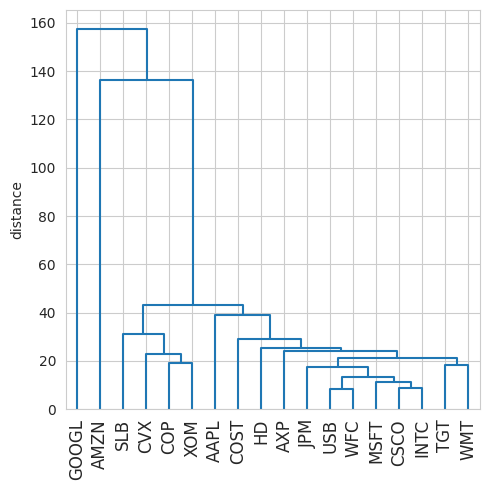

In [10]:
syms1 = ['AAPL', 'AMZN', 'AXP', 'COP', 'COST', 'CSCO', 'CVX', 'GOOGL', 'HD',
         'INTC', 'JPM', 'MSFT', 'SLB', 'TGT', 'USB', 'WFC', 'WMT', 'XOM']
df = sp500_px.loc[sp500_px.index >= '2011-01-01', syms1].transpose()

Z = linkage(df, method='complete')
print(Z.shape)

fig, ax = plt.subplots(figsize=(5, 5))
dendrogram(Z, labels=list(df.index), color_threshold=0)
plt.xticks(rotation=90); ax.set_ylabel('distance')
plt.tight_layout(); plt.show()

In [11]:
memb = fcluster(Z, 4, criterion='maxclust')
memb = pd.Series(memb, index=df.index)
for key, item in memb.groupby(memb):
    print(f"{key} : {', '.join(item.index)}")

1 : COP, CVX, SLB, XOM
2 : AAPL, AXP, COST, CSCO, HD, INTC, JPM, MSFT, TGT, USB, WFC, WMT
3 : AMZN
4 : GOOGL


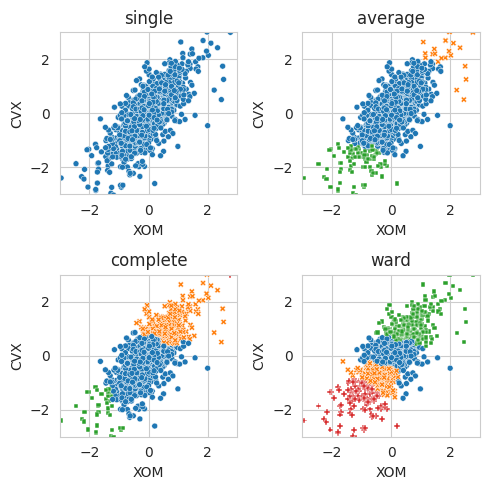

In [12]:
# Effect of the linkage method
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
for i, method in enumerate(['single', 'average', 'complete', 'ward']):
    ax = axes[i // 2, i % 2]
    Z = linkage(df, method=method)
    colors = [f'C{c+1}' for c in fcluster(Z, 4, criterion='maxclust')]
    ax = sns.scatterplot(x='XOM', y='CVX', hue=colors, style=colors, size=0.5, ax=ax, data=df, legend=False)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_title(method)
plt.tight_layout(); plt.show()

## 4. Model-Based Clustering
**Penjelasan teori.** Metode ini mengasumsikan data berasal dari **campuran beberapa distribusi peluang**, biasanya normal multivariat, yang masing-masing mewakili satu klaster:
$$f(x)=\sum_{k=1}^{K}\pi_k\,\mathcal N(x\mid\mu_k,\Sigma_k)$$
- Parameternya (bobot campuran $\pi_k$, rata-rata $\mu_k$, kovarians $\Sigma_k$) diestimasi dengan **Expectation-Maximization (EM)**. *Langkah E* menghitung peluang tiap titik masuk ke tiap komponen, dan *langkah M* memperbarui parameter.
- Hasilnya berupa **penetapan lunak** (probabilitas) dan membolehkan klaster elips dengan bentuk dan ukuran berbeda (lewat struktur kovarians: `full`, `tied`, `diag`, `spherical`).
- **Memilih jumlah klaster.** **BIC** (Bayesian Information Criterion) menyeimbangkan kecocokan dengan jumlah parameter. Fungsi `bic()` di sklearn berlaku *makin kecil makin baik*.
- K-means adalah kasus khusus dengan kovarians bulat yang sama dan penetapan keras.

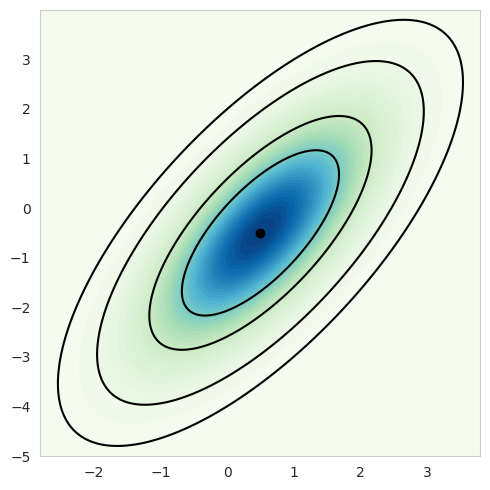

In [13]:
# A 2-D multivariate normal: probability contours
mean = [0.5, -0.5]
cov = [[1, 1], [1, 2]]
probability = [.5, .75, .95, .99]

def probLevel(p):
    D = 1
    return (1 - p) / (2 * math.pi * D)

levels = [probLevel(p) for p in probability]
fig, ax = plt.subplots(figsize=(5, 5))
x, y = np.mgrid[-2.8:3.8:.01, -5:4:.01]
pos = np.empty(x.shape + (2,)); pos[:, :, 0] = x; pos[:, :, 1] = y
rv = multivariate_normal(mean, cov)
CS = ax.contourf(x, y, rv.pdf(pos), cmap=cm.GnBu, levels=50)
ax.contour(CS, levels=levels, colors=['black'])
ax.plot(*mean, color='black', marker='o')
plt.tight_layout(); plt.show()

BIC: 4589.92885731864


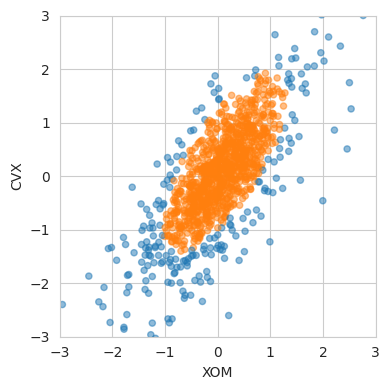

Mean
[[-0.05031426 -0.21161823]
 [ 0.07246995  0.10494619]]
Covariances
[[[0.97123064 0.97764343]
  [0.97764343 1.67233845]]

 [[0.26822676 0.27562091]
  [0.27562091 0.51679853]]]


In [14]:
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
mclust = GaussianMixture(n_components=2, random_state=1).fit(df)
print('BIC:', mclust.bic(df))

fig, ax = plt.subplots(figsize=(4, 4))
colors = [f'C{c}' for c in mclust.predict(df)]
df.plot.scatter(x='XOM', y='CVX', c=colors, alpha=0.5, ax=ax)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()

print('Mean'); print(mclust.means_)
print('Covariances'); print(mclust.covariances_)

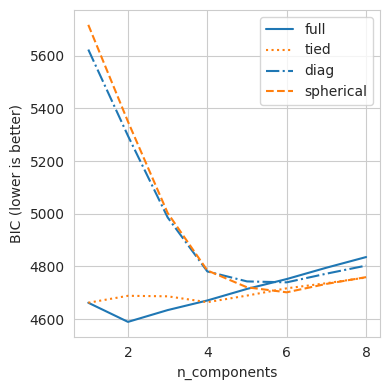

           bic  n_components covariance_type
4  4589.928857             2            full
8  4634.636319             3            full
1  4662.479542             1            tied


In [15]:
# Selecting the number of clusters with BIC
results = []
covariance_types = ['full', 'tied', 'diag', 'spherical']
for n_components in range(1, 9):
    for covariance_type in covariance_types:
        mclust = GaussianMixture(n_components=n_components, warm_start=True,
                                 covariance_type=covariance_type, random_state=1)
        mclust.fit(df)
        results.append({'bic': mclust.bic(df), 'n_components': n_components,
                        'covariance_type': covariance_type})
results = pd.DataFrame(results)

styles = ['C0-', 'C1:', 'C0-.', 'C1--']
fig, ax = plt.subplots(figsize=(4, 4))
for i, covariance_type in enumerate(covariance_types):
    subset = results.loc[results.covariance_type == covariance_type, :]
    subset.plot(x='n_components', y='bic', ax=ax, label=covariance_type, kind='line', style=styles[i])
ax.set_ylabel('BIC (lower is better)')
plt.tight_layout(); plt.show()
print(results.sort_values('bic').head(3))

## 5. Penskalaan dan Variabel Kategorikal
**Penjelasan teori.** Metode unsupervised bergantung pada **jarak**, jadi satuan variabel sangat berpengaruh.
- **Penskalaan.** Variabel dengan rentang angka besar (misalnya `revol_bal` dan `annual_inc` dalam dolar) akan mendominasi jarak. Karena itu data perlu **distandarkan** (z-score, dikurangi rata-rata lalu dibagi simpangan baku) atau dinormalisasi sebelum PCA, K-means, atau hierarchical clustering. Pilihan penskalaan bersifat keputusan, kadang kita memang sengaja *memberi bobot lebih* pada suatu variabel.
- **Variabel dominan.** Walaupun sudah diskalakan, variabel dengan varians tinggi di PCA tetap bisa mendominasi komponen pertama.
- **Data kategorikal.** Pakai **one-hot encoding** (lalu diskalakan, dan kalau perlu bobot dummy dikecilkan supaya tidak mendominasi), atau **jarak Gower** yang menskalakan kontribusi tiap variabel ke rentang [0, 1] (numerik: selisih mutlak dibagi rentang, kategorikal: 0 kalau sama dan 1 kalau beda). Jarak Gower cocok untuk metode hierarkis, sedangkan K-means butuh input numerik sehingga perlu one-hot encoding.

In [16]:
loan_data = pd.read_csv(DATA / 'loan_data.csv.gz')
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], categories=['paid off', 'default'], ordered=True)
defaults = loan_data.loc[loan_data['outcome'] == 'default', ]

columns = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 'dti', 'revol_util']
df = defaults[columns]

kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df)
counts = Counter(kmeans.labels_)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers['size'] = [counts[i] for i in range(4)]
print('Without scaling (dominated by annual_inc and revol_bal):')
print(centers)

Without scaling (dominated by annual_inc and revol_bal):
      loan_amnt     annual_inc     revol_bal   open_acc        dti  \
0  17809.760881   78669.452556  18933.405997  11.594003  17.016428   
1  21444.318867  148736.057263  33152.689572  12.376733  13.831145   
2  24290.909091  409746.465909  84710.988636  13.431818   8.148636   
3  10274.160906   41241.205530   9950.095008   9.480338  17.718588   

   revol_util   size  
0   62.183810   7906  
1   63.151084   1654  
2   60.015647     88  
3   57.903425  13023  


In [17]:
scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df0)
counts = Counter(kmeans.labels_)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=columns)
centers['size'] = [counts[i] for i in range(4)]
print('With standardisation:')
print(centers)

With standardisation:
      loan_amnt     annual_inc     revol_bal   open_acc        dti  \
0  13484.728906   55907.993263  16435.803337  14.322265  24.211535   
1  25950.205142  116834.142232  32945.972921  12.396335  16.165914   
2  10507.283093   51117.994063  11635.285252   7.509513  15.931561   
3  10324.846369   53456.824767   6054.819926   8.664618  11.312983   

   revol_util  size  
0   59.463608  6244  
1   66.123542  3670  
2   77.795077  7397  
3   30.999874  5360  


### Variabel Dominan pada PCA

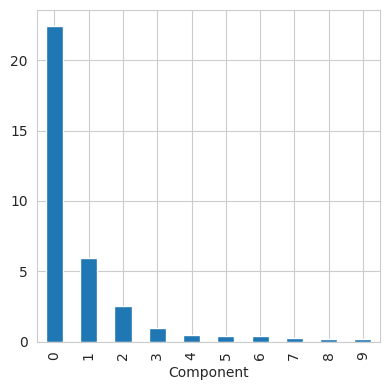

              0         1
GOOGL  0.857310 -0.477873
AMZN   0.444728  0.874149
AAPL   0.071627  0.020802
MSFT   0.036002  0.006204
CSCO   0.029205  0.003045
INTC   0.026666  0.006069
CVX    0.089548  0.037420
XOM    0.080336  0.020511
SLB    0.110218  0.030356
COP    0.057739  0.024117
JPM    0.071228  0.009244
WFC    0.053228  0.008597
USB    0.041670  0.005952
AXP    0.078907  0.024027
WMT    0.040346  0.007141
TGT    0.063659  0.024662
HD     0.051412  0.032922
COST   0.071403  0.033826


In [18]:
syms = ['GOOGL', 'AMZN', 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM',
        'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST']
top_sp1 = sp500_px.loc[sp500_px.index >= '2005-01-01', syms]

sp_pca1 = PCA()
sp_pca1.fit(top_sp1)

explained_variance = pd.DataFrame(sp_pca1.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')
plt.tight_layout(); plt.show()

loadings = pd.DataFrame(sp_pca1.components_[0:2, :], columns=top_sp1.columns)
print(loadings.transpose())

Memasukkan data krisis 2008 sampai 2009 dan saham Google/Amazon (yang harganya bergerak besar) membuat **GOOGL dan AMZN mendominasi** dua komponen pertama. Ini masalah penskalaan.

### Data Kategorikal dan Jarak Gower

In [19]:
x = defaults[['dti', 'payment_inc_ratio', 'home_', 'purpose_']].loc[0:4, :]
print(x)

# Gower's distance computed by hand (numeric: range-scaled |difference|; categorical: 0 if equal else 1)
def gower_matrix(d):
    num = d.select_dtypes('number'); cat = d.select_dtypes(exclude='number')
    dist = np.zeros((len(d), len(d)))
    for c in num:
        r = (num[c].max() - num[c].min()) or 1
        dist += np.abs(num[c].to_numpy()[:, None] - num[c].to_numpy()[None, :]) / r
    for c in cat:
        dist += (cat[c].to_numpy(dtype=object)[:, None] != cat[c].to_numpy(dtype=object)[None, :]).astype(float)
    return dist / d.shape[1]

print(pd.DataFrame(gower_matrix(x).round(3), index=x.index, columns=x.index))

     dti  payment_inc_ratio home_            purpose_
0   1.00            2.39320  RENT      major_purchase
1   5.55            4.57170   OWN      small_business
2  18.08            9.71600  RENT               other
3  10.08           12.21520  RENT  debt_consolidation
4   7.06            3.90888  RENT               other
       0      1      2      3      4
0  0.000  0.622  0.686  0.633  0.377
1  0.622  0.000  0.814  0.761  0.539
2  0.686  0.814  0.000  0.431  0.309
3  0.633  0.761  0.431  0.000  0.506
4  0.377  0.539  0.309  0.506  0.000


In [20]:
# K-means on mixed data: one-hot encode, then scale
columns = ['dti', 'payment_inc_ratio', 'home_', 'pub_rec_zero']
df = pd.get_dummies(defaults[columns], dtype=int)

scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df0)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df.columns)
print(centers)

         dti  payment_inc_ratio  pub_rec_zero  home__MORTGAGE     home__OWN  \
0  21.431365          12.354001      0.943315   -1.421085e-14 -2.900458e-15   
1  12.743276           5.918701      0.900372   -6.772360e-15 -3.635980e-15   
2  17.339786           8.353535      0.905716    1.000000e+00 -9.742207e-15   
3  17.197993           9.266666      0.917903    1.582068e-14  1.000000e+00   

     home__RENT  
0  1.000000e+00  
1  1.000000e+00  
2  8.282264e-14  
3  1.831868e-14  


## Poin Penting
- **PCA** mereduksi variabel yang berkorelasi menjadi beberapa komponen yang tidak berkorelasi (scree plot dan loading dipakai untuk interpretasi), sedangkan **correspondence analysis** melakukan hal serupa untuk tabel kategorikal.
- **K-means** cepat dan skalabel (K dipilih dengan elbow). **Hierarchical clustering** memberi dendrogram lengkap dan hasilnya bergantung pada linkage. **Model-based clustering (GMM)** memberi penetapan probabilistik dan pemilihan *K* lewat BIC.
- Selalu **skalakan** variabel, dan tangani variabel kategorikal dengan one-hot encoding atau jarak Gower, karena metode berbasis jarak peka terhadap satuan.